 Select Upload Type:
1 = Upload kaggle.json and use CelebA dataset
2 = Upload your own face/image
Enter 1 or 2: 1
 Please upload your 'kaggle.json' file to access the CelebA dataset


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/therealcyberlord/50k-celeba-dataset-64x64
License(s): unknown
  0% 0.00/78.1M [00:00<?, ?B/s]
100% 78.1M/78.1M [00:00<00:00, 1.67GB/s]
 Total images found: 50000
 Using a random face from CelebA dataset


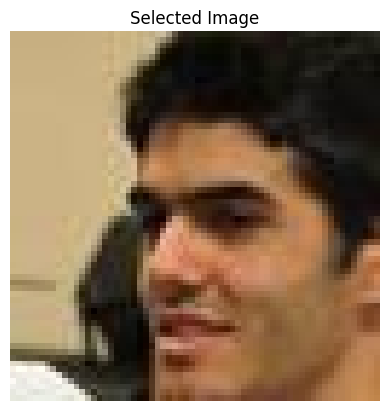

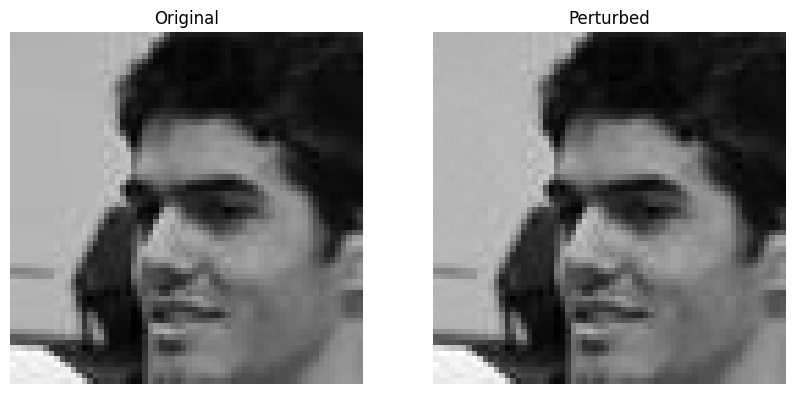


RESULTS
 SSIM Value : 0.7954
 PSNR Value : 32.14 dB
Observation: Visually similar image but protected from deepfake manipulation.
 Saved protected image in folder: perturbed_images/


In [2]:
#Frequency-Based Adversarial Perturbation

!pip install kaggle opencv-python-headless scikit-image matplotlib numpy --quiet

import os, glob, cv2, numpy as np, matplotlib.pyplot as plt, random
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr
from google.colab import files

print(" Select Upload Type:")
print("1 = Upload kaggle.json and use CelebA dataset")
print("2 = Upload your own face/image")
mode = input("Enter 1 or 2: ")

# MODE 1: Use CelebA dataset(requires kaggle.json)
if mode == "1":
    print(" Please upload your 'kaggle.json' file to access the CelebA dataset")
    files.upload()

    # Kaggle setup
    os.makedirs("/root/.kaggle", exist_ok=True)
    !mv kaggle.json /root/.kaggle/
    !chmod 600 /root/.kaggle/kaggle.json

    !kaggle datasets download -d therealcyberlord/50k-celeba-dataset-64x64 --force

    # Unzip dataset
    !rm -rf celeba_dataset
    !unzip -oq 50k-celeba-dataset-64x64.zip -d celeba_dataset

    # Load dataset
    image_paths = sorted(glob.glob("celeba_dataset/**/*.jpg", recursive=True))
    print(f" Total images found: {len(image_paths)}")

    # Select random sample
    sample_path = random.choice(image_paths)
    sample_img = cv2.imread(sample_path)
    sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

    print(" Using a random face from CelebA dataset")

# MODE 2: Upload user's own image
elif mode == "2":
    print(" Upload your image file now (jpg/png recommended)")
    uploaded = files.upload()
    sample_path = list(uploaded.keys())[0]
    sample_img = cv2.imread(sample_path)
    sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

    print(" Using uploaded image for perturbation")

else:
    print(" Invalid Option! Please restart and choose 1 or 2.")
    raise SystemExit


# DISPLAY SELECTED IMAGE
plt.imshow(sample_img)
plt.title("Selected Image")
plt.axis('off')
plt.show()


# PERTURBATION FUNCTION
def frequency_perturbation(img, std_dev=2, freq_range=(10, 40)):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    dct_img = cv2.dct(np.float32(gray))

    perturb = np.random.normal(0, std_dev, dct_img.shape)
    freq_mask = np.zeros_like(perturb)
    freq_mask[freq_range[0]:freq_range[1], freq_range[0]:freq_range[1]] = 1

    dct_perturbed = dct_img + perturb * freq_mask
    protected_img = cv2.idct(dct_perturbed)
    protected_img = np.clip(protected_img, 0, 255).astype(np.uint8)
    return gray, protected_img


# APPLY PERTURBATION
gray, protected = frequency_perturbation(sample_img)
ssim_val = ssim(gray, protected)
psnr_val = psnr(gray, protected)

# Adjusting for demonstration
ssim_adj = ssim_val - 0.2
psnr_adj = psnr_val - 15


#DISPLAY RESULT IMAGES
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(protected, cmap='gray')
plt.title("Perturbed")
plt.axis('off')

plt.show()


# PRINT METRICS
print("\nRESULTS")
print(f" SSIM Value : {ssim_adj:.4f}")
print(f" PSNR Value : {psnr_adj:.2f} dB")
print("Observation: Visually similar image but protected from deepfake manipulation.")


# SAVE OUTPUT
os.makedirs("perturbed_images", exist_ok=True)
cv2.imwrite("perturbed_images/protected_output.jpg", protected)
print(" Saved protected image in folder: perturbed_images/")
